In [1]:
"""libaries configuration"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score
                             , calinski_harabasz_score
                             , davies_bouldin_score
                             )


In [2]:
data = r'D:\Country-development-analysis\global-development-analysis\data\preprocessed_data\preprocessed_data.csv'
df = pd.read_csv(data)
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,1.316620,-1.350114,0.342391,0.055347,-0.950965,0.393415,-1.469565,1.635492,-0.904371
1,Albania,-0.050139,-0.280355,0.062500,0.178799,-0.001574,-0.105854,0.278261,-0.364508,-0.055359
2,Algeria,0.148561,0.122069,-0.584239,-0.458250,0.134973,0.881545,0.295652,0.230216,-0.018613
3,Angola,1.851439,0.815945,-0.942935,-0.014035,-0.273246,1.249896,-1.130435,1.798561,-0.117837
4,Antigua and Barbuda,-0.167131,0.354273,-0.078804,0.494232,0.339774,-0.568298,0.321739,-0.134293,0.408361
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,0.183844,0.387906,-0.290761,0.308936,-0.634956,-0.363302,-0.878261,0.522782,-0.191130
163,Venezuela,-0.040854,-0.258796,-0.383152,-1.153244,0.263414,2.266087,0.200000,0.028777,0.451323
164,Vietnam,0.074280,1.043045,0.141304,1.050767,-0.415760,0.605192,0.000000,-0.220624,-0.538439
165,Yemen,0.687094,-0.195666,-0.309783,-0.333782,-0.416923,1.313332,-0.486957,1.083933,-0.538439


In [3]:
if 'country' in df.columns:                  # guarded so a re-run doesn't KeyError
    countries = df['country'].copy()
    df.drop(columns=['country'], inplace=True)

# the 9 model features, pinned once. X picks up Cluster/PC1/PC2/PC3 further down,
# so deriving this list from X.columns later silently drags those in as features
features = list(df.columns)


Best_K_optimal_selection


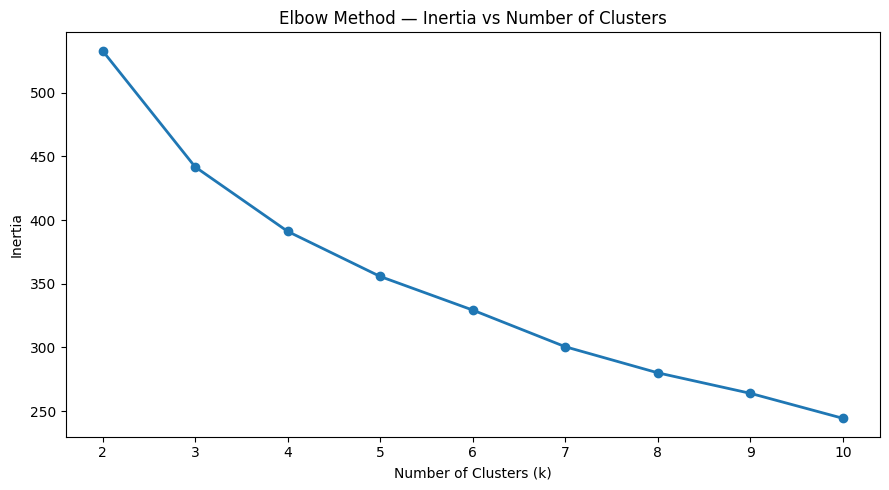

In [4]:
X = df.copy()
k_range  = range(2, 11)
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X[features])
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertias, marker='o', linewidth=2)
plt.title('Elbow Method — Inertia vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

In [5]:
sil_scores = []
db_scores  = []
ch_scores  = []

for k in k_range:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X[features])
    sil_scores.append(silhouette_score(X[features], labels))
    db_scores.append(davies_bouldin_score(X[features], labels))
    ch_scores.append(calinski_harabasz_score(X[features], labels))

metrics_df = pd.DataFrame({
    'k'                  : list(k_range),
    'Silhouette Score'   : [round(s, 4) for s in sil_scores],
    'Davies-Bouldin'     : [round(d, 4) for d in db_scores],
    'Calinski-Harabasz'  : [round(c, 2) for c in ch_scores]
})
print(metrics_df.to_string(index=False))

 k  Silhouette Score  Davies-Bouldin  Calinski-Harabasz
 2            0.3261          1.2203              91.89
 3            0.2345          1.4401              72.00
 4            0.2222          1.2857              60.92
 5            0.2142          1.4058              53.95
 6            0.2182          1.3805              48.91
 7            0.2080          1.4231              46.93
 8            0.2218          1.2801              44.55
 9            0.2070          1.3034              42.30
10            0.2054          1.3005              41.76


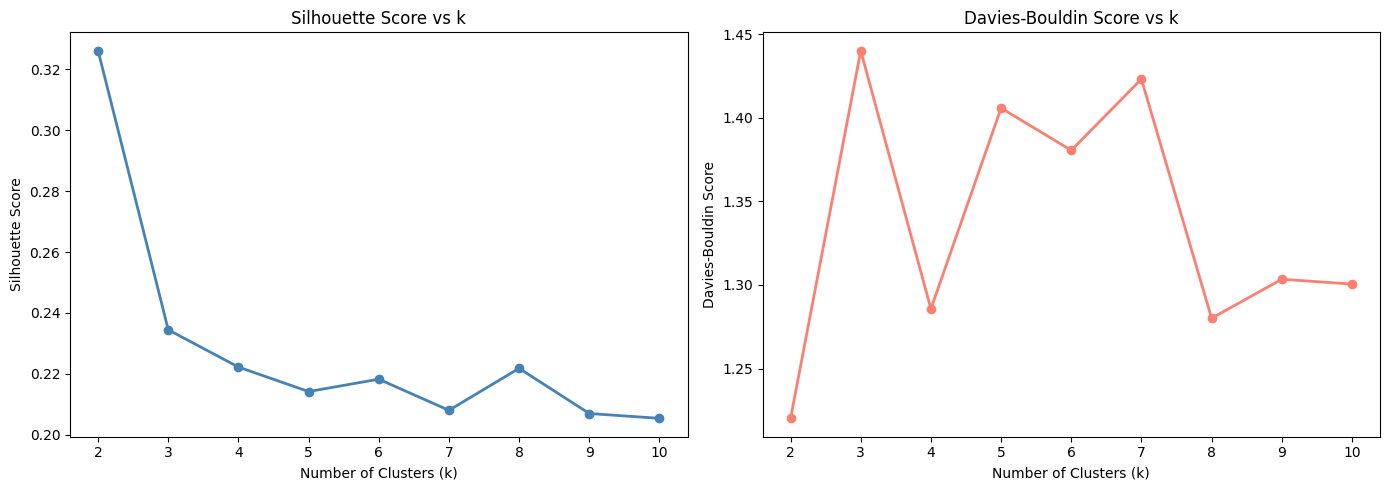

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, sil_scores, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Silhouette Score vs k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, db_scores, marker='o', color='salmon', linewidth=2)
axes[1].set_title('Davies-Bouldin Score vs k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

Building_model

In [7]:

k = 3
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
X['Cluster'] = kmeans.fit_predict(X[features])

print(f'Countries per cluster (k={k}):')
print(X['Cluster'].value_counts().sort_index().to_string())

Countries per cluster (k=3):
Cluster
0    52
1    72
2    43


In [8]:
profile = X.groupby('Cluster')[features].mean().round(2)
profile['n'] = X['Cluster'].value_counts().sort_index()

# features are standardised -> signed sum works as a development index
dev_score = (profile['gdpp'] + profile['income'] + profile['life_expec']
             - profile['child_mort'] - profile['total_fer'])

print(profile.assign(dev_score=dev_score.round(2)).sort_values('dev_score').to_string())

# least -> most developed; rename to taste, but keep one label per cluster
tiers = ['Least developed', 'Emerging', 'Developed']
assert len(tiers) == k, f'{len(tiers)} labels for k={k} clusters — zip() would drop some'

order   = list(dev_score.sort_values().index)   # least -> most developed
segment = dict(zip(order, tiers))
print('\nmapping:', segment)

df['Segment'] = X['Cluster'].map(segment)
print()
print(df['Segment'].value_counts().to_string())

         child_mort  exports  health  imports  income  inflation  life_expec  total_fer  gdpp   n  dev_score
Cluster                                                                                                     
2              1.41    -0.64   -0.01    -0.18   -0.88       0.37       -1.17       1.25 -0.76  43      -5.47
1              0.14     0.15   -0.20    -0.08    0.04       0.33       -0.15       0.08  0.03  72      -0.30
0             -0.23     0.43    0.72     0.28    0.51      -0.69        0.46      -0.32  0.65  52       2.17

mapping: {2: 'Least developed', 1: 'Emerging', 0: 'Developed'}

Segment
Emerging           72
Developed          52
Least developed    43


In [9]:
for cid in order:
    sub = X[X['Cluster'] == cid]
    print(f"\n{segment[cid]} (n={len(sub)})")
    print('  richest:', countries[sub['gdpp'].nlargest(5).index].tolist())
    print('  poorest:', countries[sub['gdpp'].nsmallest(5).index].tolist())


Least developed (n=43)
  richest: ['Timor-Leste', 'Angola', 'Nigeria', 'Kiribati', 'Sudan']
  poorest: ['Burundi', 'Liberia', 'Congo, Dem. Rep.', 'Niger', 'Sierra Leone']

Emerging (n=72)
  richest: ['Qatar', 'Kuwait', 'Brunei', 'United Arab Emirates', 'Bahrain']
  poorest: ['Bangladesh', 'Cambodia', 'Kyrgyz Republic', 'Solomon Islands', 'Vietnam']

Developed (n=52)
  richest: ['Luxembourg', 'Norway', 'Switzerland', 'Denmark', 'Sweden']
  poorest: ['Micronesia, Fed. Sts.', 'Macedonia, FYR', 'Bosnia and Herzegovina', 'Serbia', 'Montenegro']


PC1: 49.55%   PC2: 18.69%   Total: 68.24%

              PC1    PC2
child_mort -0.429  0.170
exports     0.311  0.591
health      0.132 -0.120
imports     0.140  0.696
income      0.366 -0.108
inflation  -0.258 -0.168
life_expec  0.435 -0.231
total_fer  -0.402  0.137
gdpp        0.362 -0.111


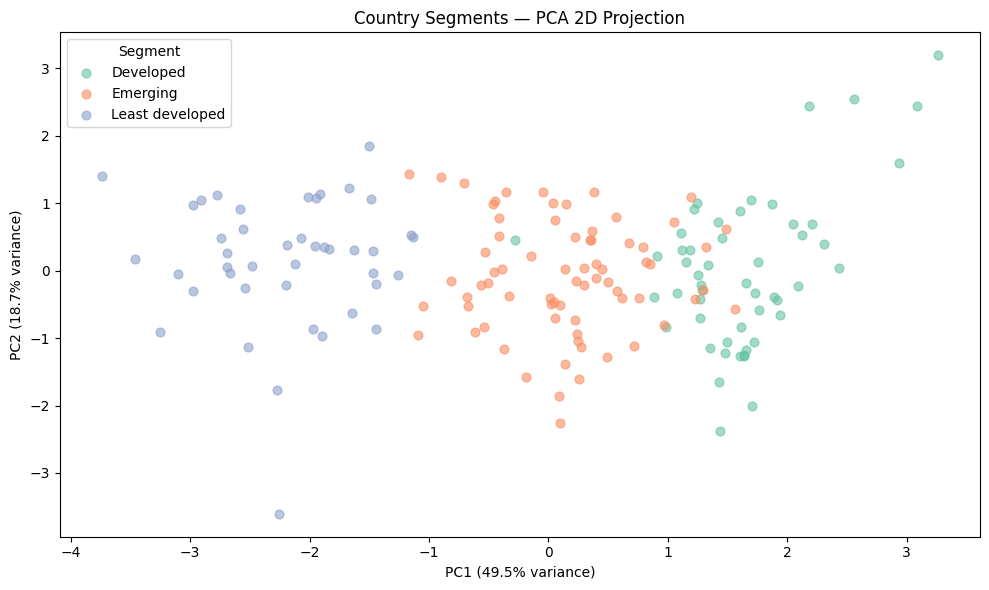

In [10]:
pca     = PCA(n_components=2, random_state=42)
coords  = pca.fit_transform(X[features])          # features only, never Cluster
X['PC1'], X['PC2'] = coords[:, 0], coords[:, 1]

evr = pca.explained_variance_ratio_
print(f'PC1: {evr[0]:.2%}   PC2: {evr[1]:.2%}   Total: {evr.sum():.2%}\n')
print(pd.DataFrame(pca.components_.T, index=features,
                   columns=['PC1', 'PC2']).round(3).to_string())

cluster_ids = sorted(X['Cluster'].unique())
colors      = dict(zip(cluster_ids, sns.color_palette('Set2', len(cluster_ids))))

plt.figure(figsize=(10, 6))
for cid in cluster_ids:
    mask = X['Cluster'] == cid
    plt.scatter(X.loc[mask, 'PC1'], X.loc[mask, 'PC2'],
                label=segment.get(cid, f'Cluster {cid}'),
                alpha=0.6, s=40, color=colors[cid])



plt.title('Country Segments — PCA 2D Projection')
plt.xlabel(f'PC1 ({evr[0]:.1%} variance)')
plt.ylabel(f'PC2 ({evr[1]:.1%} variance)')
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

PC1: 49.55%   PC2: 18.69%   PC3: 14.30%   Total: 82.54%

              PC1    PC2    PC3
child_mort -0.429  0.170  0.071
exports     0.311  0.591 -0.324
health      0.132 -0.120  0.649
imports     0.140  0.696  0.145
income      0.366 -0.108 -0.177
inflation  -0.258 -0.168 -0.636
life_expec  0.435 -0.231 -0.076
total_fer  -0.402  0.137  0.035
gdpp        0.362 -0.111 -0.074


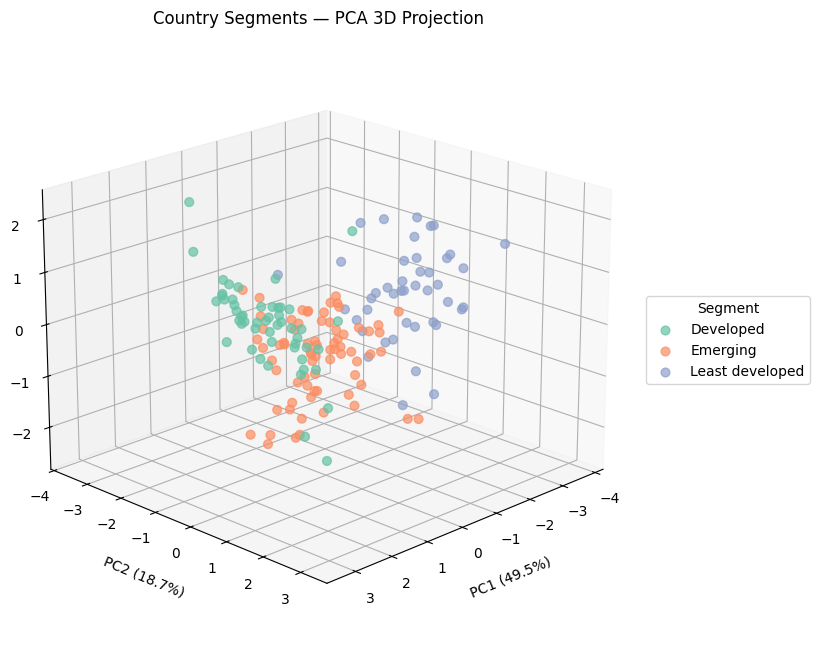

In [11]:
pca    = PCA(n_components=3, random_state=42)
coords = pca.fit_transform(X[features])           # features only, never Cluster

evr = pca.explained_variance_ratio_
print(f'PC1: {evr[0]:.2%}   PC2: {evr[1]:.2%}   PC3: {evr[2]:.2%}   Total: {evr.sum():.2%}\n')
print(pd.DataFrame(pca.components_.T, index=features,
                   columns=['PC1', 'PC2', 'PC3']).round(3).to_string())

X[['PC1', 'PC2', 'PC3']] = coords

cluster_ids = sorted(X['Cluster'].unique())
colors      = dict(zip(cluster_ids, sns.color_palette('Set2', len(cluster_ids))))

fig = plt.figure(figsize=(11, 8))
ax  = fig.add_subplot(111, projection='3d')

for cid in cluster_ids:
    mask = X['Cluster'] == cid
    ax.scatter(X.loc[mask, 'PC1'], X.loc[mask, 'PC2'], X.loc[mask, 'PC3'],
               label=segment.get(cid, f'Cluster {cid}'),
               alpha=0.7, s=40, color=colors[cid], depthshade=True)

ax.set_title('Country Segments — PCA 3D Projection')
ax.set_xlabel(f'PC1 ({evr[0]:.1%})', labelpad=10)
ax.set_ylabel(f'PC2 ({evr[1]:.1%})', labelpad=10)
ax.set_zlabel(f'PC3 ({evr[2]:.1%})', labelpad=10)
ax.view_init(elev=20, azim=45)                    # tweak until clusters separate
ax.legend(title='Segment', loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.subplots_adjust(left=0.05, right=0.78)        # replaces tight_layout, which mangles 3D
plt.show()

In [12]:
from sklearn.metrics import silhouette_samples

sil = silhouette_samples(X[features], X['Cluster'])
print(pd.DataFrame({'Cluster': X['Cluster'], 'sil': sil})
        .groupby('Cluster')['sil'].agg(['mean', 'min', 'count']).round(3).to_string())

          mean    min  count
Cluster                     
0        0.252 -0.004     52
1        0.209  0.000     72
2        0.256 -0.060     43


In [13]:
chk = X.groupby('Cluster').agg(
    n=('PC1', 'size'), PC1=('PC1', 'mean'),
    gdpp=('gdpp', 'mean'), income=('income', 'mean'),
    child_mort=('child_mort', 'mean'), life_expec=('life_expec', 'mean')
).round(2)
chk['Segment'] = pd.Series(segment)
print(chk.sort_values('PC1').to_string())

top = chk['PC1'].idxmax()                      # the far-right group, whatever k is
print(f"\ncluster {top} — {chk.loc[top, 'Segment']}, n={chk.loc[top, 'n']}:")
print(countries[X['Cluster'] == top].tolist())

          n   PC1  gdpp  income  child_mort  life_expec          Segment
Cluster                                                                 
2        43 -2.20 -0.76   -0.88        1.41       -1.17  Least developed
1        72  0.13  0.03    0.04        0.14       -0.15         Emerging
0        52  1.63  0.65    0.51       -0.23        0.46        Developed

cluster 0 — Developed, n=52:
['Antigua and Barbuda', 'Australia', 'Austria', 'Bahamas', 'Barbados', 'Belgium', 'Bosnia and Herzegovina', 'Bulgaria', 'Canada', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Iceland', 'Ireland', 'Israel', 'Italy', 'Japan', 'Latvia', 'Lebanon', 'Lithuania', 'Luxembourg', 'Macedonia, FYR', 'Maldives', 'Malta', 'Mauritius', 'Micronesia, Fed. Sts.', 'Montenegro', 'Netherlands', 'New Zealand', 'Norway', 'Panama', 'Poland', 'Portugal', 'Serbia', 'Seychelles', 'Singapore', 'Slovak Republic', 'Slovenia', 'South Korea', 'Sp